# Regression Stats Practice - Minimal Features

For gaining familiarity with using Python for regression problems instead of relying on R. Using traditional statistics techniques.

## SETUP

In [1]:
import pathlib
import json
import typing as T
import warnings

import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import sklearn.impute as skimp
import sklearn.preprocessing as skprep
import sklearn.metrics as skmetrics
import sklearn.model_selection as skm

import statsmodels.api as sm

In [2]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

## DATA COLLECTION

In [3]:
ds = datasets.load_dataset("michaelmallari/house-prices-advanced-regression-techniques")
src_df = ds["train"].to_pandas()

In [4]:
with open(pathlib.Path(".", "selected-features_minimal.json"), "r") as f:
    selected_features = json.load(f)

In [5]:
dependent_var = "SalePrice"

## DATA PREPROCESSING

In [6]:
def engineer_features(
    src_df: pd.DataFrame | T.Iterator[pd.DataFrame],
    selected_features: list[str],
) -> pd.DataFrame:
    encodable_cols = src_df.select_dtypes(["object", "str"]).nunique(dropna=True).index

    df = (
        skimp.SimpleImputer(missing_values=pd.NA, strategy="most_frequent")
        .set_output(transform="pandas")
        .fit_transform(src_df)
    )
    df = pd.get_dummies(df, columns=encodable_cols, drop_first=True, dtype="float64")
    df = df.loc[:, selected_features]

    for col in df.columns:  # polynomial transformation
        if col != dependent_var:
            df.loc[:, f"{col}_sq"] = np.square(df[col].astype("float64"))

    df = skprep.StandardScaler().set_output(transform="pandas").fit_transform(df)
    df = sm.add_constant(df)
    df.loc[:, dependent_var] = src_df[dependent_var]

    return df

In [7]:
prep_df = engineer_features(src_df, selected_features)

In [8]:
train_df, test_df = skm.train_test_split(prep_df, test_size=0.2)

In [9]:
train_df

,const,TotalBsmtSF,Foundation_PConc,OverallQual,GrLivArea,TotRmsAbvGrd,KitchenQual_TA,YearRemodAdd,GarageFinish_Unf,1stFlrSF,...,GrLivArea_sq,TotRmsAbvGrd_sq,KitchenQual_TA_sq,YearRemodAdd_sq,GarageFinish_Unf_sq,1stFlrSF_sq,BsmtQual_TA_sq,YearBuilt_sq,ExterQual_TA_sq,SalePrice
29,1.0,-1.225455,-0.892086,-1.518467,-1.895037,-1.549576,-1.006873,-1.689368,1.062205,-1.662875,...,-1.115682,-1.248343,-1.006873,-1.684124,1.062205,-1.059610,1.062205,-1.464199,0.781971,68500
776,1.0,1.269101,1.120968,0.651479,0.187581,0.296763,-1.006873,1.024029,-0.941438,1.167983,...,0.015714,0.166238,-1.006873,1.026961,-0.941438,0.950518,-0.941438,1.124374,-1.278819,221500
1318,1.0,1.586051,1.120968,1.374795,0.516916,0.296763,-1.006873,0.830215,-0.941438,1.615642,...,0.300852,0.166238,-1.006873,0.830766,-0.941438,1.457118,-0.941438,0.989128,-1.278819,275000
164,1.0,0.208801,-0.892086,-0.071836,0.191388,-0.934130,-1.006873,0.927122,1.062205,-0.035261,...,0.018845,-0.862548,-1.006873,0.928815,1.062205,-0.155713,1.062205,-1.496719,0.781971,152000
702,1.0,0.402619,1.120968,1.374795,2.018914,2.143103,-1.006873,1.024029,-0.941438,0.262316,...,1.969117,2.352410,-1.006873,1.026961,-0.941438,0.083215,-0.941438,1.158227,-1.278819,361919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1165,1.0,1.013717,1.120968,0.651479,-0.025630,0.296763,-1.006873,1.169389,-0.941438,0.878170,...,-0.153415,0.166238,-1.006873,1.174363,-0.941438,0.650030,-0.941438,1.259890,-1.278819,233170
732,1.0,0.217921,1.120968,0.651479,0.981412,0.912210,-1.006873,0.684854,-0.941438,-0.024910,...,0.752322,0.809230,-1.006873,0.683878,-0.941438,-0.147785,-0.941438,0.887871,-1.278819,222500
753,1.0,-0.062545,1.120968,1.374795,1.108958,0.912210,-1.006873,0.975575,-0.941438,-0.322487,...,0.886389,0.809230,-1.006873,0.977875,-0.941438,-0.364731,-0.941438,1.124374,-1.278819,275500
499,1.0,-0.331610,-0.892086,-0.795151,-1.148797,-0.934130,0.993174,0.006505,-0.941438,-0.648527,...,-0.843642,-0.862548,0.993174,0.001309,-0.941438,-0.576283,1.062205,-0.447705,0.781971,120000


## REGRESSION

In [10]:
def plot_homoscedasticity(residuals: pd.Series, fitted_values: pd.Series):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=fitted_values, y=residuals)
    plt.axhline(y=0, color="r", linestyle="--")
    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")
    plt.title("Linearity and Homoscedasticity")
    plt.show()

In [11]:
def plot_qq(residuals: pd.Series):
    sm.qqplot(residuals, line="45", fit=True)
    plt.title("Normal Q-Q Plot of Residuals")
    plt.show()

### Ordinary Least Squares

In [12]:
ols_results = sm.OLS(
    train_df[dependent_var], train_df.drop(dependent_var, axis=1)
).fit()

In [13]:
ols_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     406.1
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:03:07   Log-Likelihood:                -13661.
No. Observations:                1168   AIC:                         2.736e+04
Df Residuals:                    1148   BIC:                         2.746e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.822e+05    861.092    211.637      0.000    1.81e+05    1.84e+05
TotalBsmtSF          5387.7567   3392.147      1.588      0.112   -1267.747     1.2e+04
Foundation_PConc      904.0207    746.826      1.210      0.226    -561.277    2369.318
OverallQual         -5.206e+04   6504.251     -8.003      0.000   -6.48e+04   -3.93e+04
GrLivArea           -1.333e+04   5359.098     -2.488      0.013   -2.38e+04   -2817.500
TotRmsAbvGrd         6291.2642   6272.679      1.003      0.316   -6015.935    1.86e+04
KitchenQual_TA       -925.9183    632.677     -1.463      0.144   -2167.252     315.415
YearRemodAdd        -1.334e+06   2.88e+05     -4.635      0.000    -1.9e+06   -7.69e+05
GarageFinish_Unf    -2339.3142    590.136     -3.964      0.000   -3497.180   -1181.448
1stFlrSF             1.585e+04   5036.289      3.147      0.002    5967.071    2.57e+04
BsmtQual_TA         -1005.2864    673.602     -1.492      0.136   -2326.915     316.342
YearBuilt            1.004e+06   1.68e+05      5.990      0.000    6.75e+05    1.33e+06
ExterQual_TA         1024.3153    751.505      1.363      0.173    -450.161    2498.792
TotalBsmtSF_sq       1.731e+04   5025.448      3.444      0.001    7448.157    2.72e+04
Foundation_PConc_sq   904.0207    746.826      1.210      0.226    -561.277    2369.318
OverallQual_sq       8.118e+04   6660.767     12.188      0.000    6.81e+04    9.42e+04
GrLivArea_sq         5.235e+04   5146.989     10.170      0.000    4.22e+04    6.24e+04
TotRmsAbvGrd_sq     -8379.1620   6135.288     -1.366      0.172   -2.04e+04    3658.473
KitchenQual_TA_sq    -925.9183    632.677     -1.463      0.144   -2167.252     315.415
YearRemodAdd_sq      1.343e+06   2.88e+05      4.661      0.000    7.78e+05    1.91e+06
GarageFinish_Unf_sq -2339.3142    590.136     -3.964      0.000   -3497.180   -1181.448
1stFlrSF_sq         -1.962e+04   5862.692     -3.346      0.001   -3.11e+04   -8114.617
BsmtQual_TA_sq      -1005.2864    673.602     -1.492      0.136   -2326.915     316.342
YearBuilt_sq         -9.99e+05   1.69e+05     -5.921      0.000   -1.33e+06   -6.68e+05
ExterQual_TA_sq      1024.3153    751.505      1.363      0.173    -450.161    2498.792
==============================================================================
Omnibus:                      163.852   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              980.930
Skew:                           0.483   Prob(JB):                    9.85e-214
Kurtosis:                       7.384   Cond. No.                     5.70e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.12e-30. This

In [14]:
ols_residuals = ols_results.resid
ols_fitted_values = ols_results.fittedvalues

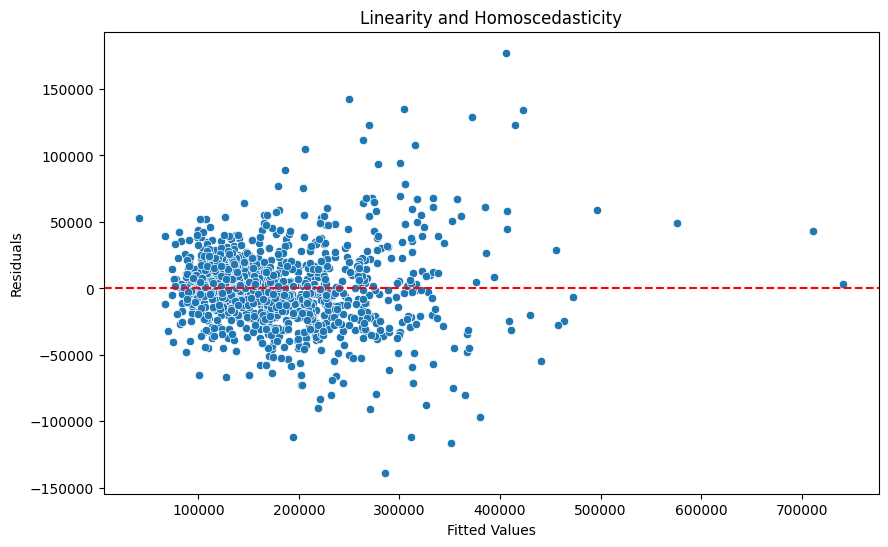

In [15]:
plot_homoscedasticity(ols_residuals, ols_fitted_values)

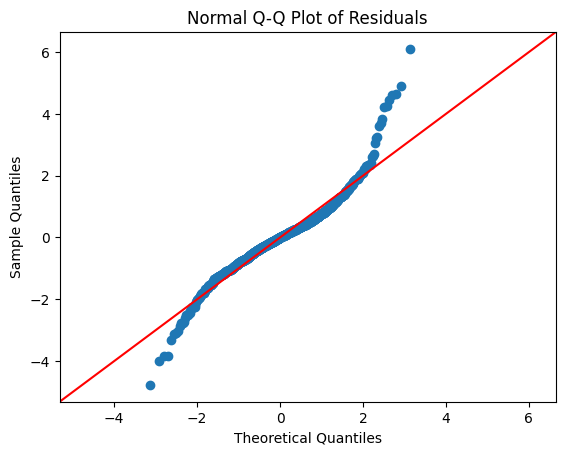

In [16]:
plot_qq(ols_residuals)  # light-tailed

In [17]:
skmetrics.mean_squared_error(
    test_df[dependent_var], ols_results.predict(test_df.drop(dependent_var, axis=1))
)

6346099053.129066

In [18]:
skmetrics.mean_absolute_error(
    test_df[dependent_var], ols_results.predict(test_df.drop(dependent_var, axis=1))
)

26316.294278557856

### Robust Linear Models

In [19]:
rlm_results = sm.RLM(
    train_df[dependent_var], train_df.drop(dependent_var, axis=1)
).fit()

In [20]:
rlm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:              SalePrice   No. Observations:                 1168
Model:                            RLM   Df Residuals:                     1148
Method:                          IRLS   Df Model:                           19
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sun, 08 Mar 2026                                         
Time:                        20:03:07                                         
No. Iterations:                     7                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.811e+05    693.480    261.128      0.000     1.8e+05    1.82e+05
TotalBsmtSF          5156.9532   2731.866      1.888      0.059    -197.406    1.05e+04
Foundation_PConc     1056.9727    601.457      1.757      0.079    -121.861    2235.806
OverallQual         -4.569e+04   5238.199     -8.722      0.000    -5.6e+04   -3.54e+04
GrLivArea           -1.729e+04   4315.950     -4.005      0.000   -2.57e+04   -8826.427
TotRmsAbvGrd         1.321e+04   5051.702      2.614      0.009    3305.471    2.31e+04
KitchenQual_TA       -642.9613    509.527     -1.262      0.207   -1641.615     355.693
YearRemodAdd         -9.39e+05   2.32e+05     -4.051      0.000   -1.39e+06   -4.85e+05
GarageFinish_Unf    -2006.0537    475.266     -4.221      0.000   -2937.558   -1074.550
1stFlrSF             1.738e+04   4055.976      4.286      0.000    9434.384    2.53e+04
BsmtQual_TA          -711.7644    542.485     -1.312      0.190   -1775.016     351.487
YearBuilt            9.016e+05   1.35e+05      6.677      0.000    6.37e+05    1.17e+06
ExterQual_TA          593.4063    605.224      0.980      0.327    -592.811    1779.624
TotalBsmtSF_sq        1.59e+04   4047.245      3.929      0.000    7970.913    2.38e+04
Foundation_PConc_sq  1056.9727    601.457      1.757      0.079    -121.861    2235.806
OverallQual_sq       7.283e+04   5364.249     13.577      0.000    6.23e+04    8.33e+04
GrLivArea_sq         5.754e+04   4145.128     13.882      0.000    4.94e+04    6.57e+04
TotRmsAbvGrd_sq     -1.595e+04   4941.055     -3.228      0.001   -2.56e+04   -6264.724
KitchenQual_TA_sq    -642.9613    509.527     -1.262      0.207   -1641.615     355.693
YearRemodAdd_sq      9.473e+05   2.32e+05      4.083      0.000    4.93e+05     1.4e+06
GarageFinish_Unf_sq -2006.0537    475.266     -4.221      0.000   -2937.558   -1074.550
1stFlrSF_sq         -2.151e+04   4721.520     -4.556      0.000   -3.08e+04   -1.23e+04
BsmtQual_TA_sq       -711.7644    542.485     -1.312      0.190   -1775.016     351.487
YearBuilt_sq        -8.959e+05   1.36e+05     -6.593      0.000   -1.16e+06    -6.3e+05
ExterQual_TA_sq       593.4063    605.224      0.980      0.327    -592.811    1779.624
=======================================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

In [21]:
rlm_residuals = rlm_results.resid
rlm_fitted_values = rlm_results.fittedvalues

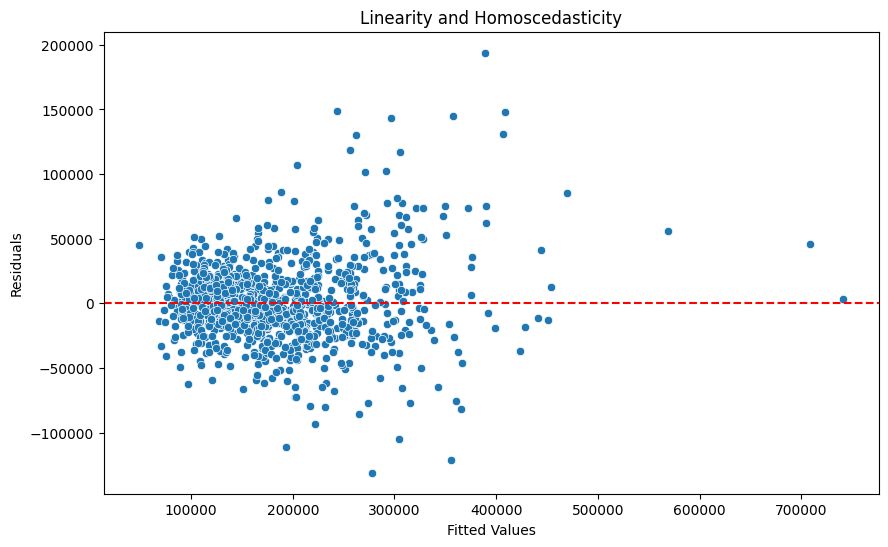

In [22]:
plot_homoscedasticity(rlm_residuals, rlm_fitted_values)

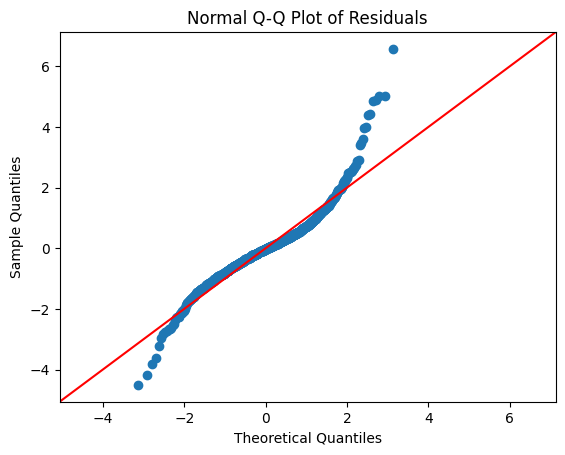

In [23]:
plot_qq(rlm_residuals)  # light-tailed

In [24]:
skmetrics.mean_squared_error(
    test_df[dependent_var], rlm_results.predict(test_df.drop(dependent_var, axis=1))
)

6044893066.42063

In [25]:
skmetrics.mean_absolute_error(
    test_df[dependent_var], rlm_results.predict(test_df.drop(dependent_var, axis=1))
)

25740.43850088049